# v4 消融实验可视化

本 notebook 只分析 v4 中重新设计并同批次训练的消融实验，不与旧版消融结果进行数值对比。

## 实验目的

消融实验通过“只改变一个结构组件，其余训练条件尽量保持一致”来判断组件贡献：

- Autoformer：检验 Auto-Correlation 和序列分解；
- PatchTST：检验 Channel Independence 和 Patching。

两个基线与四个消融变体在 ETTh1、ETTm1 的 h96、h336 上运行，共 24 组原始实验，并形成 16 个基线—消融配对。

## 差值方向

- `delta_MSE = ablation_MSE - base_MSE`
- `delta_MSE_pct = delta_MSE / base_MSE × 100%`
- `delta_R2 = ablation_R2 - base_R2`

因此 `delta_MSE_pct > 0` 或 `delta_R2 < 0` 表示消融后退化，被移除组件在当前配置下有正贡献。若出现相反结果，只能说明该变体在当前实验中更好，不能直接推出原组件没有价值。


## 1. 读取并校验消融数据

本节读取三张互相对应的汇总表：

- `summary`：24 组原始实验指标；
- `comparison`：16 个基线—消融逐任务配对；
- `mean_effect`：四种消融跨数据集、跨步长的平均影响。

校验不仅检查行数，还检查四个消融变体是否齐全。这样可以防止某个任务缺失后，平均影响被错误地解释为完整结果。


In [1]:
# 本单元集中完成依赖导入、绘图风格和项目路径初始化。
# 后续单元只负责分析与绘图，避免在每张图前重复设置环境。
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# 统一三本可视化 Notebook 的基础样式：
# 适度提高分辨率、保留浅色网格，并去掉上/右边框，使多子图更清楚。
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# 固定模型顺序，防止 pandas 按字母顺序重排后，不同图中的颜色和位置发生变化。
# LABELS 用于面向读者显示规范名称，COLORS 保证同一模型跨图始终使用同一种颜色。
MODEL_ORDER = ["lstm", "transformer", "informer", "autoformer", "patchtst"]
MODEL_LABELS = {
    "lstm": "LSTM",
    "transformer": "Transformer",
    "informer": "Informer",
    "autoformer": "Autoformer",
    "patchtst": "PatchTST",
}
MODEL_COLORS = {
    "lstm": "#6B7280",
    "transformer": "#8B5CF6",
    "informer": "#14B8A6",
    "autoformer": "#E45756",
    "patchtst": "#2F6F73",
}


# Notebook 可能从项目根目录、notebooks/visualization/ 或 nbconvert 临时环境启动。
# 因此向上搜索同时含 README.md 与 archive/ 的目录，而不是依赖固定的当前工作目录。
def find_project_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "README.md").exists() and (base / "archive").exists():
            return base
    raise FileNotFoundError("Cannot locate the Research-Training project root")


# ROOT 是后续所有输入和输出路径的唯一基准，保证移动项目目录后相对结构仍然有效。
ROOT = find_project_root()


# 所有输入和输出都限定在 v4 的 ablation_study 目录，确保不会混入旧消融结果。
BASE_DIR = ROOT / "archive/v4_results/experiments/ablation_study"
SUMMARY_CSV = BASE_DIR / "summaries/csv/ablation_rerun_seed42_summary.csv"
COMPARISON_CSV = BASE_DIR / "summaries/csv/ablation_rerun_seed42_comparison.csv"
MEAN_CSV = BASE_DIR / "summaries/csv/ablation_rerun_seed42_mean_effect.csv"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# summary 保存原始实验，comparison 保存公平配对，mean_effect 保存配对后的平均结果。
# 三张表承担不同分析层级，不能相互替代。
summary = pd.read_csv(SUMMARY_CSV)
comparison = pd.read_csv(COMPARISON_CSV)
mean_effect = pd.read_csv(MEAN_CSV)
summary["horizon"] = summary["horizon"].astype(int)
comparison["horizon"] = comparison["horizon"].astype(int)

# 固定消融顺序、可读标签和颜色，让同一变体在所有图中保持一致位置和视觉身份。
ABLATION_ORDER = [
    "autoformer_no_autocorr",
    "autoformer_no_decomp",
    "patchtst_channel_mix",
    "patchtst_no_patch",
]
ABLATION_LABELS = {
    "autoformer_no_autocorr": "Autoformer: no Auto-Correlation",
    "autoformer_no_decomp": "Autoformer: no decomposition",
    "patchtst_channel_mix": "PatchTST: channel mixing",
    "patchtst_no_patch": "PatchTST: no patching",
}
ABLATION_COLORS = {
    "autoformer_no_autocorr": "#4C78A8",
    "autoformer_no_decomp": "#E45756",
    "patchtst_channel_mix": "#F58518",
    "patchtst_no_patch": "#72B7B2",
}

# 24=2 数据集×2 步长×6 模型；16=2 数据集×2 步长×4 消融配对。
# 行数和变体集合同时满足，才认为消融矩阵完整。
assert len(summary) == 24
assert len(comparison) == 16
assert len(mean_effect) == 4
assert set(comparison["ablation_model"]) == set(ABLATION_ORDER)

display(Markdown(
    f"Loaded **{len(summary)} experiment rows**, **{len(comparison)} paired comparisons**, "
    f"and **{len(mean_effect)} mean effects**."
))
display(summary.head())

Loaded **24 experiment rows**, **16 paired comparisons**, and **4 mean effects**.

,dataset,horizon,model,run_tag,MSE,MAE,R2,MSE_target,MAE_target,R2_target,...,trained_epochs,seed,sample_limit,train_samples,val_samples,test_samples,model_params,train_time_seconds,device,data_dir
0,ETTh1,96,autoformer_ablation_base,ablation_rerun_seed42,0.540344,0.514187,0.576578,0.150418,0.305780,0.031140,...,23,42,0,8449,2689,5709,103239,36.537276,cuda,/root/workspace/data/processed
1,ETTh1,96,autoformer_no_autocorr,ablation_rerun_seed42,0.546970,0.512487,0.571386,0.156054,0.303959,-0.005166,...,16,42,0,8449,2689,5709,103239,22.348210,cuda,/root/workspace/data/processed
2,ETTh1,96,autoformer_no_decomp,ablation_rerun_seed42,0.785197,0.658323,0.384708,0.594690,0.645442,-2.830474,...,14,42,0,8449,2689,5709,103239,19.600997,cuda,/root/workspace/data/processed
3,ETTh1,96,patchtst_ablation_base,ablation_rerun_seed42,0.480989,0.472528,0.623090,0.089192,0.230684,0.425505,...,31,42,0,8449,2689,5709,100672,42.968422,cuda,/root/workspace/data/processed
4,ETTh1,96,patchtst_channel_mix,ablation_rerun_seed42,1.770190,1.053118,-0.387147,0.463736,0.574288,-1.986981,...,14,42,0,8449,2689,5709,125728,16.131830,cuda,/root/workspace/data/processed


## 2. 覆盖范围与平均消融影响

覆盖表先确认数据集、预测步长、实验数量和随机种子。平均影响表则回答“移除哪个组件的平均代价最大”。

`mean_delta_MSE_pct` 适合比较不同基线误差量级下的相对退化；`mean_delta_R2` 用于观察拟合能力变化。二者方向相反：MSE 增大是坏事，R2 减小也是坏事。


In [2]:
# coverage 用于说明实验设计是否完整，不参与后续排名。
coverage = pd.DataFrame({
    "datasets": [", ".join(sorted(summary["dataset"].unique()))],
    "horizons": [", ".join(map(str, sorted(summary["horizon"].unique())))],
    "raw experiments": [len(summary)],
    "paired comparisons": [len(comparison)],
    "seed": [int(summary["seed"].iloc[0])],
})
# 添加面向读者的消融名称，并恢复统一顺序，避免内部模型名直接出现在表格中。
mean_view = mean_effect.copy()
mean_view["ablation"] = mean_view["ablation_model"].map(ABLATION_LABELS)
mean_view = mean_view.set_index("ablation_model").reindex(ABLATION_ORDER).reset_index()

display(coverage)
display(mean_view[["ablation", "mean_delta_MSE", "mean_delta_MSE_pct", "mean_delta_R2"]].style.format({
    "mean_delta_MSE": "{:+.4f}",
    "mean_delta_MSE_pct": "{:+.1f}%",
    "mean_delta_R2": "{:+.4f}",
}))

,datasets,horizons,raw experiments,paired comparisons,seed
0,"ETTh1, ETTm1","96, 336",24,16,42


,ablation,mean_delta_MSE,mean_delta_MSE_pct,mean_delta_R2
0,Autoformer: no Auto-Correlation,-0.0207,-3.1%,+0.0163
1,Autoformer: no decomposition,+0.3865,+66.2%,-0.3041
2,PatchTST: channel mixing,+0.7212,+139.2%,-0.5665
3,PatchTST: no patching,+0.0388,+7.7%,-0.0305


## 3. 四种消融的平均影响

左图展示平均 MSE 百分比变化，右图展示平均 R2 变化：

- 左图向右越长，说明移除组件后误差增幅越大；
- 右图向左越长，说明移除组件后 R2 降幅越大；
- 接近 0 表示平均影响较小，但不代表每个任务都没有影响。

该图适合用于消融章节的总体结论，逐任务差异需结合下一节热力图。


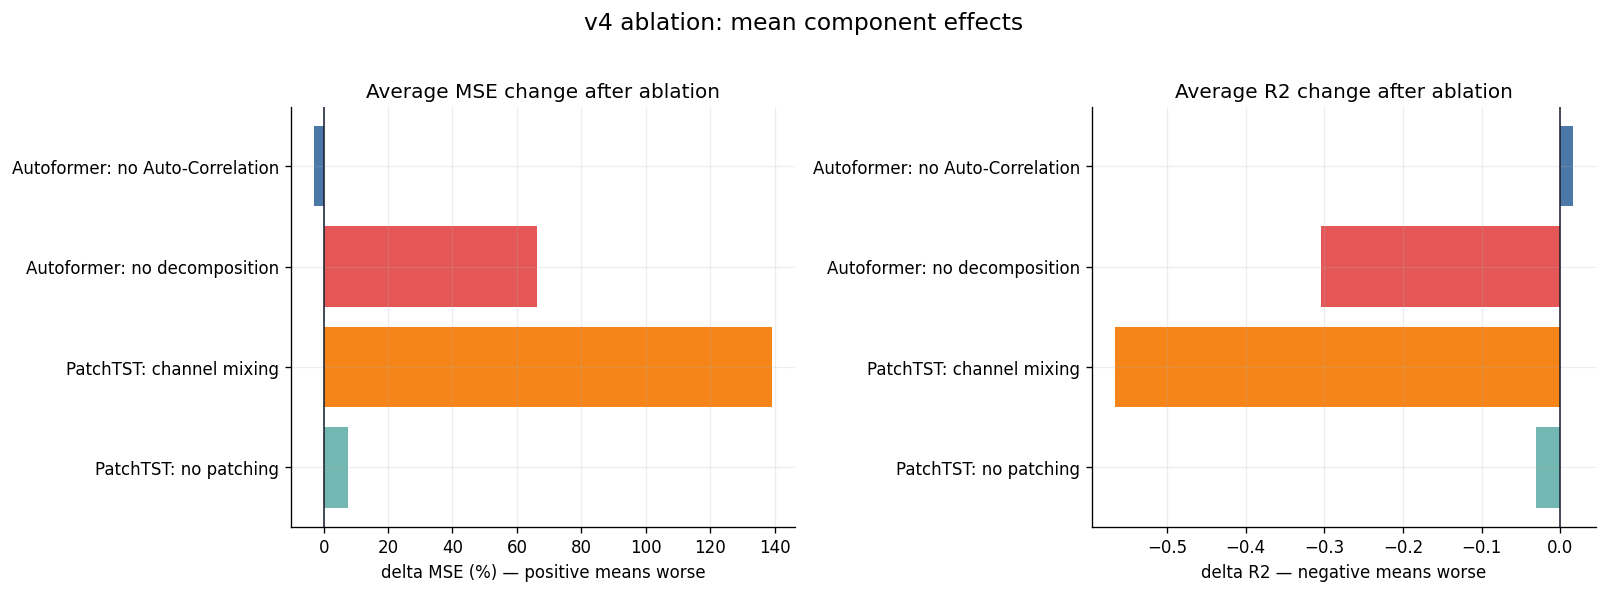

In [3]:
# 将 MSE 与 R2 并排展示，因为二者优劣方向相反，分图更不易误读。
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
# 横向条形图适合显示较长的组件名称，也便于以 0 为中心观察正负影响。
plot_mean = mean_view.set_index("ablation_model").reindex(ABLATION_ORDER)
labels = [ABLATION_LABELS[m] for m in ABLATION_ORDER]
colors = [ABLATION_COLORS[m] for m in ABLATION_ORDER]
y = np.arange(len(ABLATION_ORDER))

# MSE 图中正值表示退化；R2 图中负值表示退化，两图均绘制 0 基准线。
axes[0].barh(y, plot_mean["mean_delta_MSE_pct"], color=colors)
axes[0].axvline(0, color="#111827", linewidth=0.9)
axes[0].set_yticks(y)
axes[0].set_yticklabels(labels)
axes[0].invert_yaxis()
axes[0].set_title("Average MSE change after ablation")
axes[0].set_xlabel("delta MSE (%) — positive means worse")

axes[1].barh(y, plot_mean["mean_delta_R2"], color=colors)
axes[1].axvline(0, color="#111827", linewidth=0.9)
axes[1].set_yticks(y)
axes[1].set_yticklabels(labels)
axes[1].invert_yaxis()
axes[1].set_title("Average R2 change after ablation")
axes[1].set_xlabel("delta R2 — negative means worse")

fig.suptitle("v4 ablation: mean component effects", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "v4_ablation_mean_effects.png", bbox_inches="tight")
plt.show()

## 4. 逐数据集、逐步长的 MSE 变化热力图

热力图将 16 个配对完整展开。每行是一种消融，每列是一个预测步长，两张子图分别对应 ETTh1 和 ETTm1。

- 红色、正值：消融后 MSE 上升；
- 蓝色、负值：消融后 MSE 下降；
- 颜色越深：相对变化幅度越大。

所有子图共用以 0 为中心的对称颜色范围，因此可以跨数据集比较同一颜色深度。异常的大幅变化应回查基线 MSE，避免百分比受小分母放大。


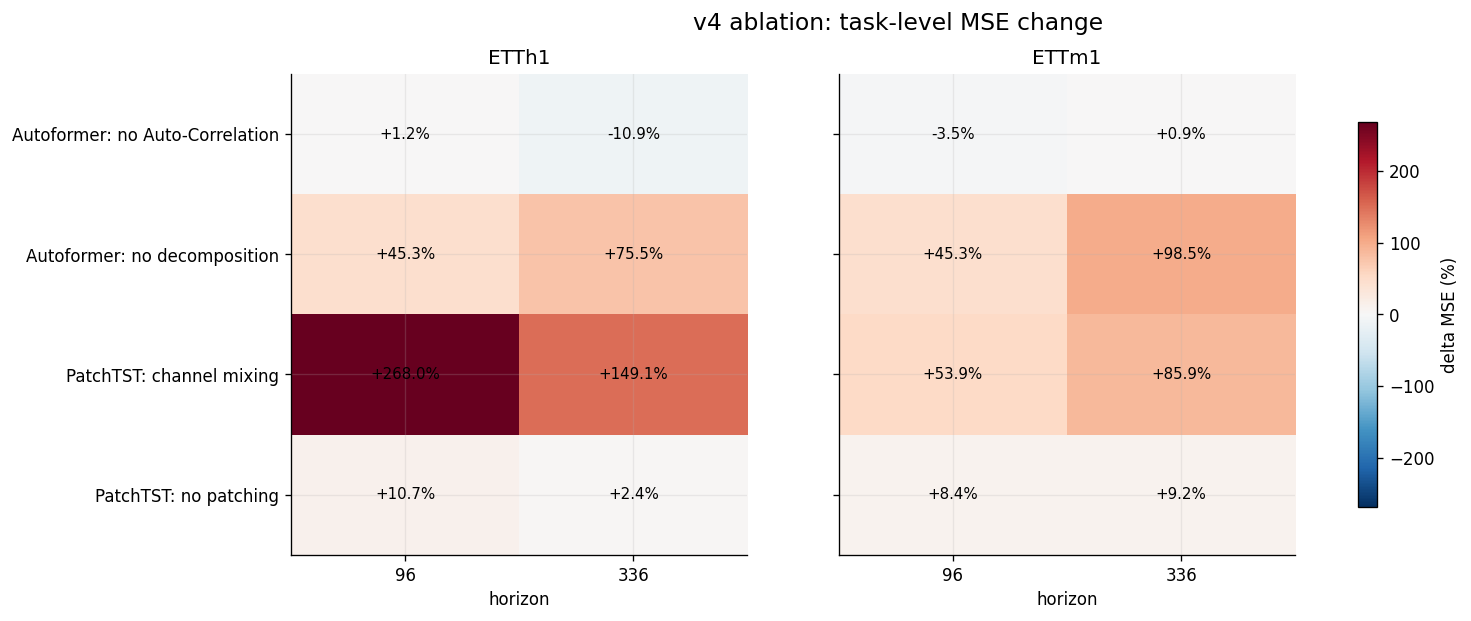

In [4]:
# 两张子图分别对应两个数据集，共用消融顺序和颜色范围。
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=True)
# 使用最大绝对变化构造关于 0 对称的色标，确保红蓝颜色可以直接解释为退化/改善。
max_abs = abs(comparison["delta_MSE_pct"]).max()

# 将长表透视为 ablation_model×horizon 矩阵；显式 reindex 保证行列顺序稳定。
for ax, dataset in zip(axes, sorted(comparison["dataset"].unique())):
    pivot = (
        comparison[comparison["dataset"] == dataset]
        .pivot(index="ablation_model", columns="horizon", values="delta_MSE_pct")
        .reindex(ABLATION_ORDER)[[96, 336]]
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-max_abs, vmax=max_abs)
    ax.set_title(dataset)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([96, 336])
    ax.set_yticks(range(len(ABLATION_ORDER)))
    ax.set_yticklabels([ABLATION_LABELS[m] for m in ABLATION_ORDER])
    ax.set_xlabel("horizon")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i, j]:+.1f}%", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="delta MSE (%)")
fig.suptitle("v4 ablation: task-level MSE change", y=0.98, fontsize=14)
fig.savefig(FIG_DIR / "v4_ablation_task_delta_heatmap.png", bbox_inches="tight")
plt.show()

## 5. 基线到消融模型的 MSE 变化轨迹

每个子图固定一个 `dataset × horizon` 任务，横轴左侧是同批次基线，右侧是消融变体。

- 线向上：消融后 MSE 增大；
- 线向下：消融后 MSE 减小；
- 斜率越大：该组件在该任务上的影响越明显。

同一子图中不同消融可能来自 Autoformer 或 PatchTST，因此比较的是各自相对对应基线的变化，不是不同模型之间的绝对公平排名。


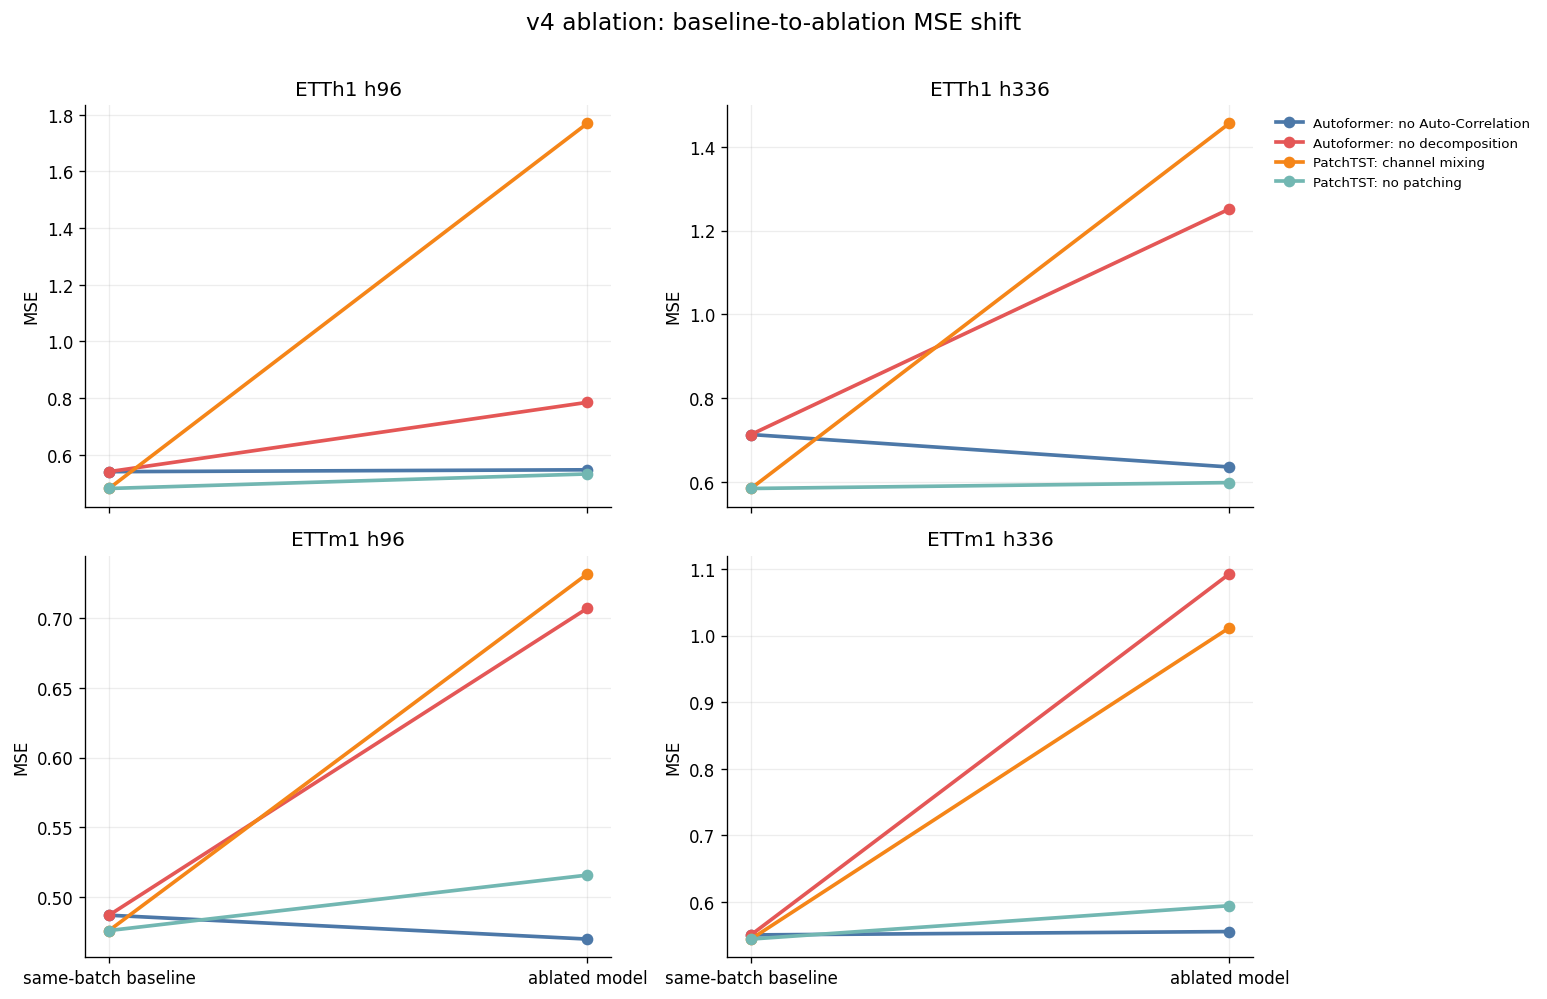

In [5]:
# 四个子图正好对应 2 个数据集×2 个预测步长。
fig, axes = plt.subplots(2, 2, figsize=(13, 8.2), sharex=True)
# 每个任务内包含四条基线到消融的连线；每条线使用对应消融的固定颜色。
tasks = list(comparison.groupby(["dataset", "horizon"]))

# 先按统一顺序排列变体，再连接各自的 base_MSE 与 ablation_MSE。
# 不同线的左端基线可能不同，因此只比较线的方向和变化幅度。
for ax, ((dataset, horizon), group) in zip(axes.ravel(), tasks):
    group = group.set_index("ablation_model").reindex(ABLATION_ORDER)
    for model, row in group.iterrows():
        ax.plot(
            [0, 1], [row["base_MSE"], row["ablation_MSE"]],
            marker="o", linewidth=2.2, color=ABLATION_COLORS[model],
            label=ABLATION_LABELS[model],
        )
    ax.set_title(f"{dataset} h{int(horizon)}")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["same-batch baseline", "ablated model"])
    ax.set_ylabel("MSE")

axes[0, 1].legend(fontsize=8, frameon=False, bbox_to_anchor=(1.02, 1))
fig.suptitle("v4 ablation: baseline-to-ablation MSE shift", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "v4_ablation_mse_slopes.png", bbox_inches="tight")
plt.show()

## 6. 目标变量 MSE 的消融影响

全变量 MSE 会平均七个变量，可能掩盖目标列上的明显变化。本节根据比较表中的
`base_MSE_target` 和 `ablation_MSE_target` 重新计算目标变量相对变化。

读图规则与上一张热力图一致。若全变量和目标变量给出不同方向，报告中应明确组件主要影响的是整体多变量预测，还是核心目标列预测。


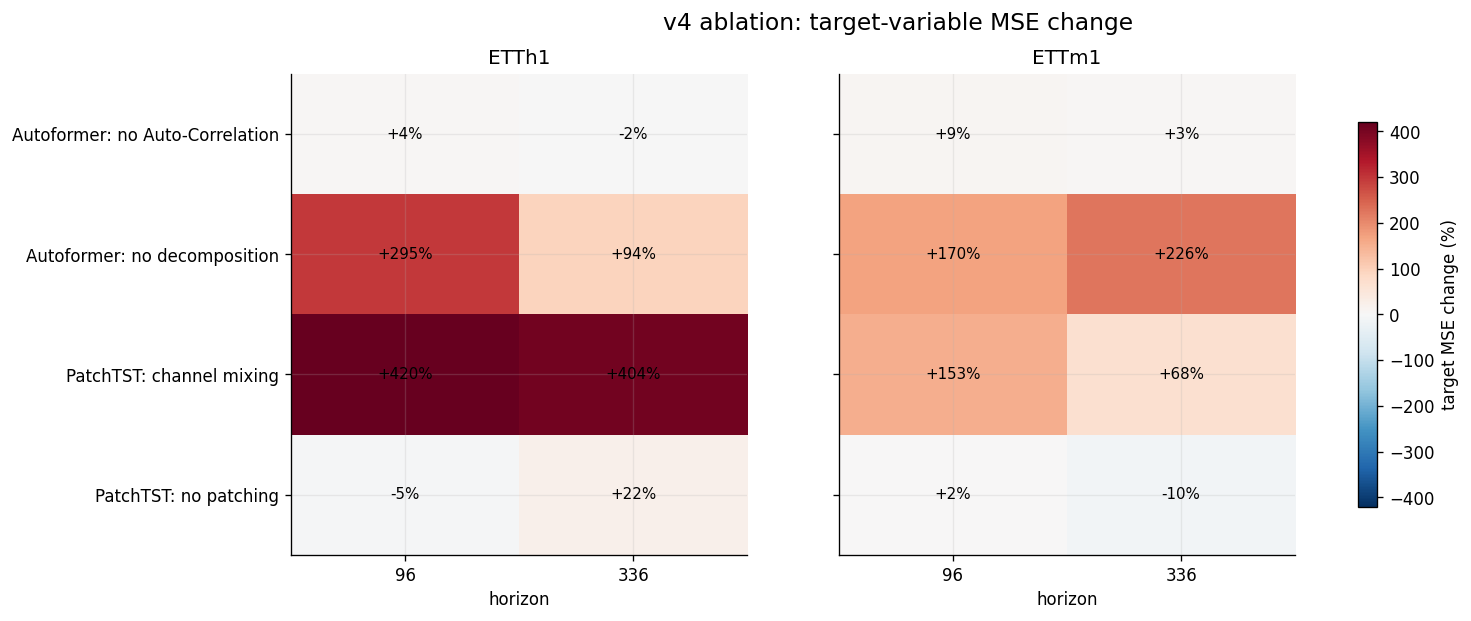

In [6]:
# comparison 没有预先保存目标变量差值，因此在这里由原始基线/消融指标现场计算。
target_effect = comparison.copy()
target_effect["delta_MSE_target"] = target_effect["ablation_MSE_target"] - target_effect["base_MSE_target"]
# 使用基线目标 MSE 作为分母；正值表示目标列误差增大。
target_effect["delta_MSE_target_pct"] = (
    target_effect["ablation_MSE_target"] / target_effect["base_MSE_target"] - 1
) * 100

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=True)
# 目标变量变化可能远大于全变量变化，因此单独计算颜色范围，避免图像失去层次。
max_abs_target = abs(target_effect["delta_MSE_target_pct"]).max()

for ax, dataset in zip(axes, sorted(target_effect["dataset"].unique())):
    pivot = (
        target_effect[target_effect["dataset"] == dataset]
        .pivot(index="ablation_model", columns="horizon", values="delta_MSE_target_pct")
        .reindex(ABLATION_ORDER)[[96, 336]]
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-max_abs_target, vmax=max_abs_target)
    ax.set_title(dataset)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([96, 336])
    ax.set_yticks(range(len(ABLATION_ORDER)))
    ax.set_yticklabels([ABLATION_LABELS[m] for m in ABLATION_ORDER])
    ax.set_xlabel("horizon")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i, j]:+.0f}%", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="target MSE change (%)")
fig.suptitle("v4 ablation: target-variable MSE change", y=0.98, fontsize=14)
fig.savefig(FIG_DIR / "v4_ablation_target_delta_heatmap.png", bbox_inches="tight")
plt.show()

## 7. 参数量和训练时间变化

消融可能降低误差，也可能通过简化结构减少参数和训练时间。本节同时计算：

- 参数量相对变化；
- 训练时间相对变化；
- MSE 相对变化。

左图显示资源变化，右图把训练时间变化与 MSE 代价放在同一平面。训练时间受硬件、早停轮数和算子实现影响，因此这里只讨论本批实验内部的相对效率。


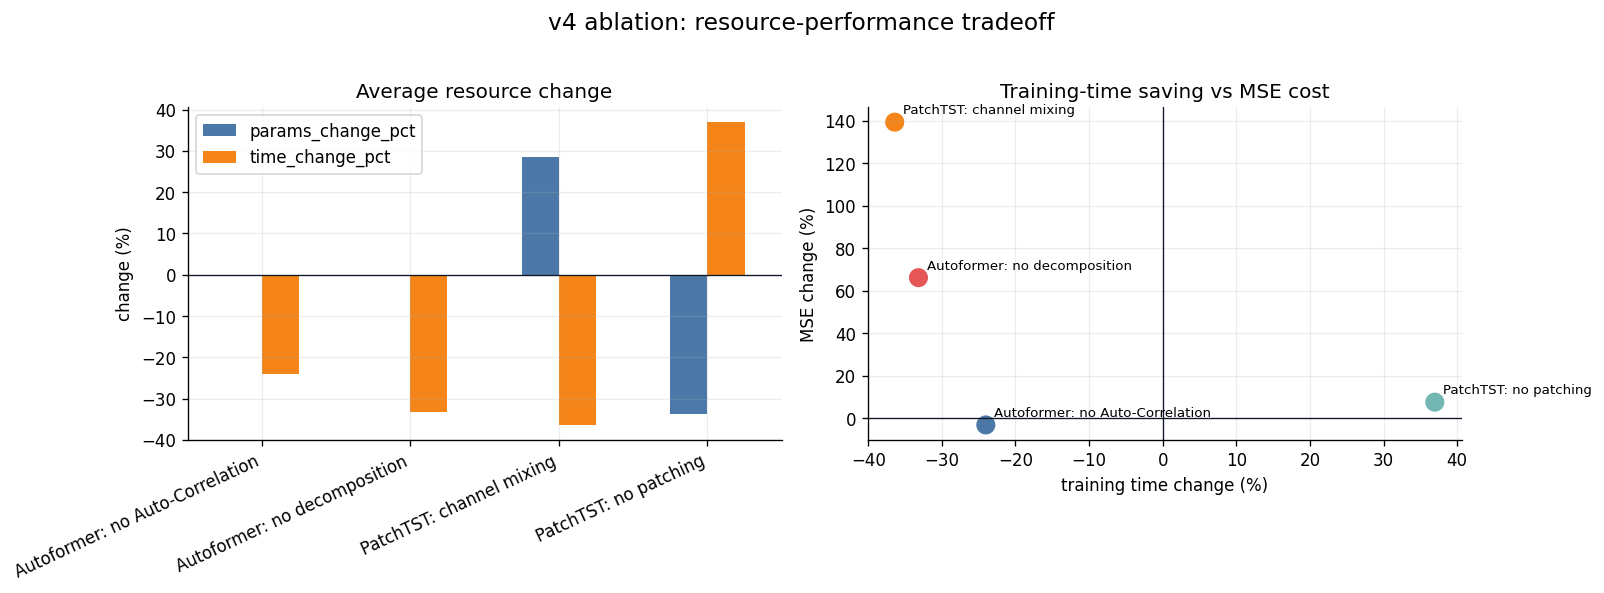

,params_change_pct,time_change_pct,MSE_change_pct
ablation_model,,,
autoformer_no_autocorr,+0.0%,-24.0%,-3.1%
autoformer_no_decomp,+0.0%,-33.2%,+66.2%
patchtst_channel_mix,+28.5%,-36.4%,+139.2%
patchtst_no_patch,-33.8%,+37.0%,+7.7%


In [7]:
# 参数量和训练时间均使用相对基线的百分比变化，使不同模型规模可以放在同一图中比较。
resource_effect = comparison.copy()
resource_effect["params_change_pct"] = (
    resource_effect["ablation_params"] / resource_effect["base_params"] - 1
) * 100
resource_effect["time_change_pct"] = (
    resource_effect["ablation_train_time_seconds"] / resource_effect["base_train_time_seconds"] - 1
) * 100
# 对四个 dataset×horizon 任务取平均，得到每种消融的典型资源变化和性能代价。
resource_avg = (
    resource_effect.groupby("ablation_model", as_index=False)
    .agg(
        params_change_pct=("params_change_pct", "mean"),
        time_change_pct=("time_change_pct", "mean"),
        MSE_change_pct=("delta_MSE_pct", "mean"),
    )
    .set_index("ablation_model")
    .reindex(ABLATION_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
# 左图回答“省了多少资源”，右图回答“节省训练时间是否伴随明显误差代价”。
resource_avg[["params_change_pct", "time_change_pct"]].plot(
    kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"]
)
axes[0].axhline(0, color="#111827", linewidth=0.8)
axes[0].set_title("Average resource change")
axes[0].set_ylabel("change (%)")
axes[0].set_xlabel("")
axes[0].set_xticklabels([ABLATION_LABELS[m] for m in ABLATION_ORDER], rotation=25, ha="right")

axes[1].scatter(
    resource_avg["time_change_pct"], resource_avg["MSE_change_pct"],
    s=150, color=[ABLATION_COLORS[m] for m in ABLATION_ORDER],
    edgecolor="white", linewidth=0.8,
)
for model, row in resource_avg.iterrows():
    axes[1].annotate(
        ABLATION_LABELS[model],
        (row["time_change_pct"], row["MSE_change_pct"]),
        xytext=(5, 5), textcoords="offset points", fontsize=8,
    )
# 0 线把平面划分为改善/退化象限：左侧更快，右侧更慢；下方更准，上方更差。
axes[1].axhline(0, color="#111827", linewidth=0.8)
axes[1].axvline(0, color="#111827", linewidth=0.8)
axes[1].set_title("Training-time saving vs MSE cost")
axes[1].set_xlabel("training time change (%)")
axes[1].set_ylabel("MSE change (%)")

fig.suptitle("v4 ablation: resource-performance tradeoff", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "v4_ablation_resource_tradeoff.png", bbox_inches="tight")
plt.show()

display(resource_avg.style.format("{:+.1f}%"))

## 8. 自动结论与输出文件

自动结论统计平均影响最大的消融、影响最小的消融，以及 16 个配对中有多少出现误差上升。

对于“移除 Auto-Correlation 后平均略有改善”这类反常现象，应使用谨慎表述：它可能来自当前实现、超参数、样本特征或注意力机制适配差异，需要进一步验证，不能直接写成 Auto-Correlation 没有作用。


In [8]:
# 按平均 MSE 百分比排序，分别提取退化最大和变化最小的消融。
worst = mean_view.sort_values("mean_delta_MSE_pct", ascending=False).iloc[0]
best = mean_view.sort_values("mean_delta_MSE_pct").iloc[0]
# 配对计数直接使用 delta 的符号，避免平均值抵消后掩盖多数任务的方向。
worse_pairs = int((comparison["delta_MSE"] > 0).sum())
target_worse_pairs = int((target_effect["delta_MSE_target"] > 0).sum())

# 自动结论只报告数据事实，并主动保留对反常负向消融结果的解释边界。
report_lines = [
    f"v4 消融分析包含 {len(summary)} 组原始实验和 {len(comparison)} 个基线—消融配对。",
    f"平均退化最明显的是 {worst['ablation']}，MSE 平均变化 {worst['mean_delta_MSE_pct']:+.1f}%。",
    f"平均 MSE 变化最小的是 {best['ablation']}，变化为 {best['mean_delta_MSE_pct']:+.1f}%。",
    f"16 个配对中有 {worse_pairs} 个在消融后全变量 MSE 上升，{target_worse_pairs} 个在目标变量 MSE 上升。",
    "负向消融结果只说明当前配置下该变体表现更好，仍需结合公平调参和实现差异解释。",
]
display(Markdown("\n".join(f"- {line}" for line in report_lines)))

outputs = [
    "v4_ablation_mean_effects.png",
    "v4_ablation_task_delta_heatmap.png",
    "v4_ablation_mse_slopes.png",
    "v4_ablation_target_delta_heatmap.png",
    "v4_ablation_resource_tradeoff.png",
]
display(Markdown("**Saved figures**\n\n" + "\n".join(f"- `{name}`" for name in outputs)))

- v4 消融分析包含 24 组原始实验和 16 个基线—消融配对。
- 平均退化最明显的是 PatchTST: channel mixing，MSE 平均变化 +139.2%。
- 平均 MSE 变化最小的是 Autoformer: no Auto-Correlation，变化为 -3.1%。
- 16 个配对中有 14 个在消融后全变量 MSE 上升，13 个在目标变量 MSE 上升。
- 负向消融结果只说明当前配置下该变体表现更好，仍需结合公平调参和实现差异解释。

**Saved figures**

- `v4_ablation_mean_effects.png`
- `v4_ablation_task_delta_heatmap.png`
- `v4_ablation_mse_slopes.png`
- `v4_ablation_target_delta_heatmap.png`
- `v4_ablation_resource_tradeoff.png`